In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


In [11]:
DATA_DIR = Path("..") / "dataset"
df_train = pd.read_json(DATA_DIR / "train.json")
df_test = pd.read_json(DATA_DIR / "test.json")

df_train.head()

,transaction_date,year,month,dept_code,dept_name,region_code,region_name,transaction_type,future_sale,property_value,...,area_apt_1_room,area_apt_2_rooms,area_apt_3_rooms,area_apt_4_rooms,area_apt_5plus_rooms,area_house_1_room,area_house_2_rooms,area_house_3_rooms,area_house_4_rooms,area_house_5plus_rooms
0,2015-06-29,2015,6,86,Vienne,75,Nouvelle-Aquitaine,Vente,False,58000.0,...,0,0,0,0,0,0,0,0,0,0
1,2020-11-26,2020,11,86,Vienne,75,Nouvelle-Aquitaine,Vente,False,58000.0,...,34,0,0,0,0,0,0,0,0,0
2,2016-03-16,2016,3,86,Vienne,75,Nouvelle-Aquitaine,Vente en l'état futur d'achèvement,True,169000.0,...,0,0,61,0,0,0,0,0,0,0
3,2020-06-19,2020,6,86,Vienne,75,Nouvelle-Aquitaine,Vente,False,73000.0,...,0,0,60,0,0,0,0,0,0,0
4,2021-05-26,2021,5,86,Vienne,75,Nouvelle-Aquitaine,Vente,False,208000.0,...,0,0,0,0,0,0,0,0,0,0


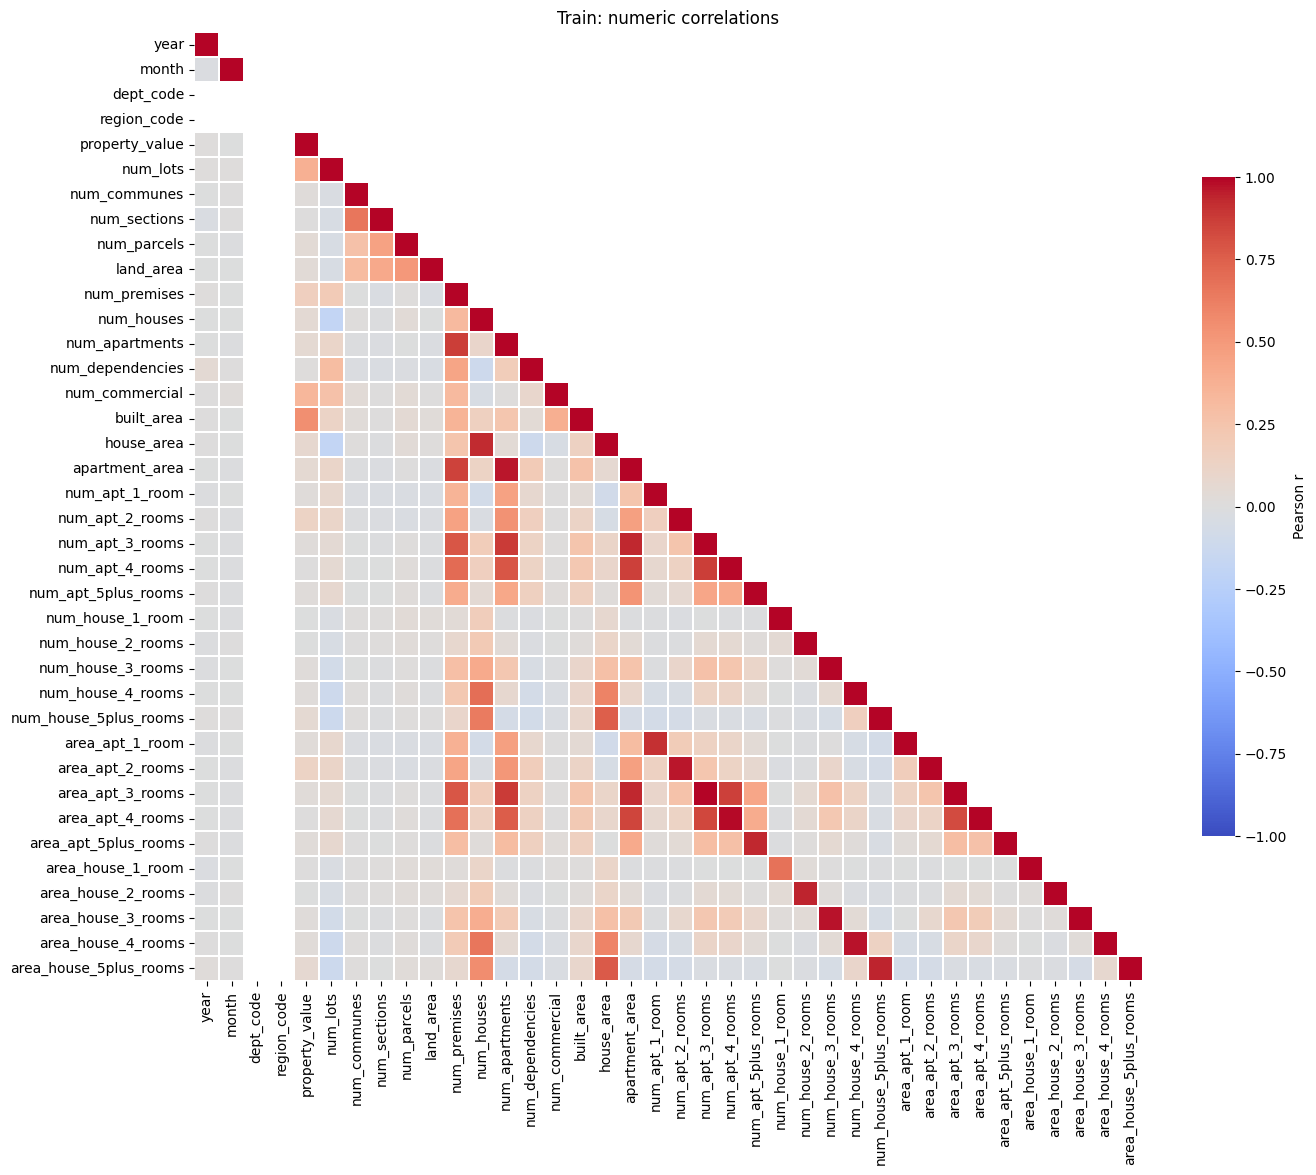

In [12]:
corr = df_train.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.35,
    cbar_kws={"shrink": 0.65, "label": "Pearson r"},
)
plt.title("Train: numeric correlations")
plt.tight_layout()

In [3]:
df_train.columns

Index(['transaction_date', 'year', 'month', 'dept_code', 'dept_name',
       'region_code', 'region_name', 'transaction_type', 'future_sale',
       'property_value', 'num_lots', 'num_communes', 'commune_codes',
       'num_sections', 'cadastral_sections', 'num_parcels', 'parcel_ids',
       'transferred_parcel_ids', 'land_area', 'num_premises', 'num_houses',
       'num_apartments', 'num_dependencies', 'num_commercial', 'built_area',
       'house_area', 'apartment_area', 'property_type', 'num_apt_1_room',
       'num_apt_2_rooms', 'num_apt_3_rooms', 'num_apt_4_rooms',
       'num_apt_5plus_rooms', 'num_house_1_room', 'num_house_2_rooms',
       'num_house_3_rooms', 'num_house_4_rooms', 'num_house_5plus_rooms',
       'area_apt_1_room', 'area_apt_2_rooms', 'area_apt_3_rooms',
       'area_apt_4_rooms', 'area_apt_5plus_rooms', 'area_house_1_room',
       'area_house_2_rooms', 'area_house_3_rooms', 'area_house_4_rooms',
       'area_house_5plus_rooms'],
      dtype='object')

In [4]:
df_train[["built_area", "num_lots", "num_commercial"]]

,built_area,num_lots,num_commercial
0,0,0,0
1,34,3,0
2,61,3,0
3,60,2,0
4,247,0,1
...,...,...,...
27363,110,0,0
27364,0,0,0
27365,132,0,0
27366,77,3,0


In [5]:
df_train['region_name'].unique().tolist()

['Nouvelle-Aquitaine']

In [6]:
columns_numeric = df_train.select_dtypes(include=["number", "bool"]).columns.tolist()
columns_numeric

df_train_numeric = df_train[columns_numeric]
df_train_numeric

,year,month,dept_code,region_code,future_sale,property_value,num_lots,num_communes,num_sections,num_parcels,...,area_apt_1_room,area_apt_2_rooms,area_apt_3_rooms,area_apt_4_rooms,area_apt_5plus_rooms,area_house_1_room,area_house_2_rooms,area_house_3_rooms,area_house_4_rooms,area_house_5plus_rooms
0,2015,6,86,75,False,58000.0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2020,11,86,75,False,58000.0,3,1,1,1,...,34,0,0,0,0,0,0,0,0,0
2,2016,3,86,75,True,169000.0,3,1,1,1,...,0,0,61,0,0,0,0,0,0,0
3,2020,6,86,75,False,73000.0,2,1,1,1,...,0,0,60,0,0,0,0,0,0,0
4,2021,5,86,75,False,208000.0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27363,2017,1,86,75,False,85000.0,0,1,1,1,...,0,0,0,0,0,0,0,110,0,0
27364,2015,3,86,75,False,27032.0,0,1,1,6,...,0,0,0,0,0,0,0,0,0,0
27365,2015,6,86,75,False,183500.0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,132
27366,2019,6,86,75,False,75000.0,3,1,1,1,...,0,0,0,77,0,0,0,0,0,0


In [9]:
df_train_numeric.corr(numeric_only=True)

,year,month,dept_code,region_code,future_sale,property_value,num_lots,num_communes,num_sections,num_parcels,...,area_apt_1_room,area_apt_2_rooms,area_apt_3_rooms,area_apt_4_rooms,area_apt_5plus_rooms,area_house_1_room,area_house_2_rooms,area_house_3_rooms,area_house_4_rooms,area_house_5plus_rooms
year,1.000000,-0.016412,NaN,NaN,0.074797,0.014351,0.012501,-0.005209,-0.023925,-0.006204,...,-0.015052,-0.000059,-0.004944,-0.006080,0.002334,-0.017965,-0.011811,-0.007021,0.002898,0.015682
month,-0.016412,1.000000,NaN,NaN,0.063209,-0.001168,0.015607,0.005546,0.003144,-0.012507,...,-0.007714,-0.015456,-0.008733,-0.010303,-0.012494,-0.007773,0.005137,-0.001205,-0.003796,0.002560
dept_code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region_code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
future_sale,0.074797,0.063209,NaN,NaN,1.000000,0.026748,0.118127,-0.016709,-0.029143,-0.040536,...,-0.041189,0.003834,-0.001168,-0.007912,-0.014648,-0.016584,-0.030491,-0.044822,-0.067151,-0.078623
property_value,0.014351,-0.001168,NaN,NaN,0.026748,1.000000,0.379414,0.020964,0.000901,0.044362,...,0.023822,0.128332,0.025398,0.003581,0.030023,0.001774,-0.004736,0.021029,0.029604,0.067920
num_lots,0.012501,0.015607,NaN,NaN,0.118127,0.379414,1.000000,-0.029617,-0.039225,-0.041441,...,0.079102,0.116777,0.055708,0.069597,0.077863,-0.024084,-0.043566,-0.079388,-0.114640,-0.122943
num_communes,-0.005209,0.005546,NaN,NaN,-0.016709,0.020964,-0.029617,1.000000,0.658940,0.268302,...,-0.018331,-0.011842,-0.005978,-0.007609,0.001013,0.007755,0.000404,-0.004217,0.009092,0.012400
num_sections,-0.023925,0.003144,NaN,NaN,-0.029143,0.000901,-0.039225,0.658940,1.000000,0.460062,...,-0.025097,-0.020590,-0.008836,-0.008033,-0.002069,0.011793,0.011361,-0.009631,-0.013648,-0.006701
num_parcels,-0.006204,-0.012507,NaN,NaN,-0.040536,0.044362,-0.041441,0.268302,0.460062,1.000000,...,-0.030246,-0.024587,0.011401,0.020898,0.010978,0.027857,0.030421,0.012527,0.016690,0.023591


In [8]:
df_train_numeric.columns

Index(['year', 'month', 'dept_code', 'region_code', 'future_sale',
       'property_value', 'num_lots', 'num_communes', 'num_sections',
       'num_parcels', 'land_area', 'num_premises', 'num_houses',
       'num_apartments', 'num_dependencies', 'num_commercial', 'built_area',
       'house_area', 'apartment_area', 'num_apt_1_room', 'num_apt_2_rooms',
       'num_apt_3_rooms', 'num_apt_4_rooms', 'num_apt_5plus_rooms',
       'num_house_1_room', 'num_house_2_rooms', 'num_house_3_rooms',
       'num_house_4_rooms', 'num_house_5plus_rooms', 'area_apt_1_room',
       'area_apt_2_rooms', 'area_apt_3_rooms', 'area_apt_4_rooms',
       'area_apt_5plus_rooms', 'area_house_1_room', 'area_house_2_rooms',
       'area_house_3_rooms', 'area_house_4_rooms', 'area_house_5plus_rooms'],
      dtype='object')

In [ ]:
df_train["transaction_type"].unique().tolist()

In [ ]:
features = [
    # Location + time
    "year",
    "month",
    "dept_code",
    "region_code",
    "future_sale",
    # Transaction/property size
    "num_lots",
    "num_parcels",
    "land_area",
    "built_area",
    "house_area",
    "apartment_area",
    # Property composition
    "num_premises",
    "num_houses",
    "num_apartments",
    "num_dependencies",
    "num_commercial",
    # Apartment detail
    "num_apt_1_room",
    "num_apt_2_rooms",
    "num_apt_3_rooms",
    "num_apt_4_rooms",
    "num_apt_5plus_rooms",
    "area_apt_1_room",
    "area_apt_2_rooms",
    "area_apt_3_rooms",
    "area_apt_4_rooms",
    "area_apt_5plus_rooms",
    # House detail
    "num_house_1_room",
    "num_house_2_rooms",
    "num_house_3_rooms",
    "num_house_4_rooms",
    "num_house_5plus_rooms",
    "area_house_1_room",
    "area_house_2_rooms",
    "area_house_3_rooms",
    "area_house_4_rooms",
    "area_house_5plus_rooms",
]


In [ ]:
relevant_features = [
    # Target variable 
    "property_value",

    # Property type
    "property_type",
    
    # Transaction/property size
    "num_lots",
    "land_area",
    "built_area",
    "house_area",
    "apartment_area",
    # Property composition
    "num_premises",
    "num_houses",
    "num_apartments",
    "num_dependencies",
    "num_commercial",
]

df_train_top_relevant = df_train[relevant_features]

df_train_top_relevant.head()
df_train_top_relevant.shape

In [ ]:
df_train_top_relevant

In [ ]:
df_train_top_relevant

In [ ]:
sns.pairplot(df_train_top_relevant)